In [1]:
%pip install "numpy" "opencv-python" -q
%pip install git+https://www.github.com/mouseland/cellpose.git
%pip install pyocclient -q

  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-iqwgfxb8
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-iqwgfxb8
  Resolved https://www.github.com/mouseland/cellpose.git to commit 849ca11f17882219f9968217eab3f6b19e3ce8aa
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 77.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 76.7 MB/s eta 0:00:00:00:0100:01
  Created wheel for cellpose: filename=cellpose-4.0.10.dev21+g849ca11f1-py3-none-any.whl size=213402 sha256=9687569122a9cf56a2f2999c4cb9e488518520b88830bf0a79bef6bdea97fae6
  Stored in directory: /tmp/pip-ephem-wheel-cache-b_nte88b/wheels/df/b6/31/a3013c44290eabb46f4c06d1efb19744124fcad2d59684ec5e
Successfully built cellpose
  Preparing metadata (setup.py) ... done


In [3]:
import owncloud, getpass, cellpose

# Config
url, user = 'https://cloud.minesparis.psl.eu', 'gabriel.gautier'
oc_session = owncloud.Client(url)
oc_session.login(user, getpass.getpass(f"PW {user}: "))
oc_session.get_file('/travail/Mines/DIMA/Segmentation/scripts/tool.py', 'tool.py')

import tool
oc = tool.Owncloud(oc_session)

print("Tool chargé et prêt.")

Tool chargé et prêt.


In [4]:
!nvcc --version
!nvidia-smi

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
Fri Mar 20 12:43:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0       

In [5]:
oc.upload_data()

In [6]:
import os, shutil
import numpy as np
import matplotlib.pyplot as plt
import cv2

from cellpose import core, utils, io, models, metrics, train, dynamics, transforms, plot
from glob import glob

import importlib

In [7]:
oc.upload_scripts()
oc.upload_models()
importlib.reload(tool)
import tool

visualizer = tool.CellVisualizer()

In [8]:
use_GPU = core.use_gpu()
yn = ['NO', 'YES']
print(f'>>> GPU activated? {yn[use_GPU]}')

>>> GPU activated? YES


In [8]:

io.logger_setup()

model = models.CellposeModel(gpu=True)

path = '001'
img = visualizer.load_data(path, mode='Image')

masks_pred, flows, styles = model.eval(img, niter=1000)


output_dir = './data/prediction/cellpose4/'
os.makedirs(output_dir, exist_ok=True)

filename = os.path.basename(path)
name_without_ext = os.path.splitext(filename)[0]
save_path = os.path.join(output_dir, f"{name_without_ext}_Cell_pred.bmp")

cv2.imwrite(save_path, masks_pred)

print(f"Masque sauvegardé : {save_path}")

2026-03-20 10:58:34,385 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-20 10:58:34,388 [INFO] 
cellpose version: 	4.0.10.dev21+g849ca11f1 
platform:       	linux 
python version: 	3.12.12 
torch version:  	2.10.0+cu128
2026-03-20 10:58:34,389 [INFO] ** TORCH CUDA version installed and working. **
2026-03-20 10:58:34,390 [INFO] >>>> using GPU (CUDA)
2026-03-20 10:58:36,678 [INFO] >>>> loading model /root/.cellpose/models/cpsam
Masque sauvegardé : ./data/prediction/cellpose4/001_Cell_pred.bmp


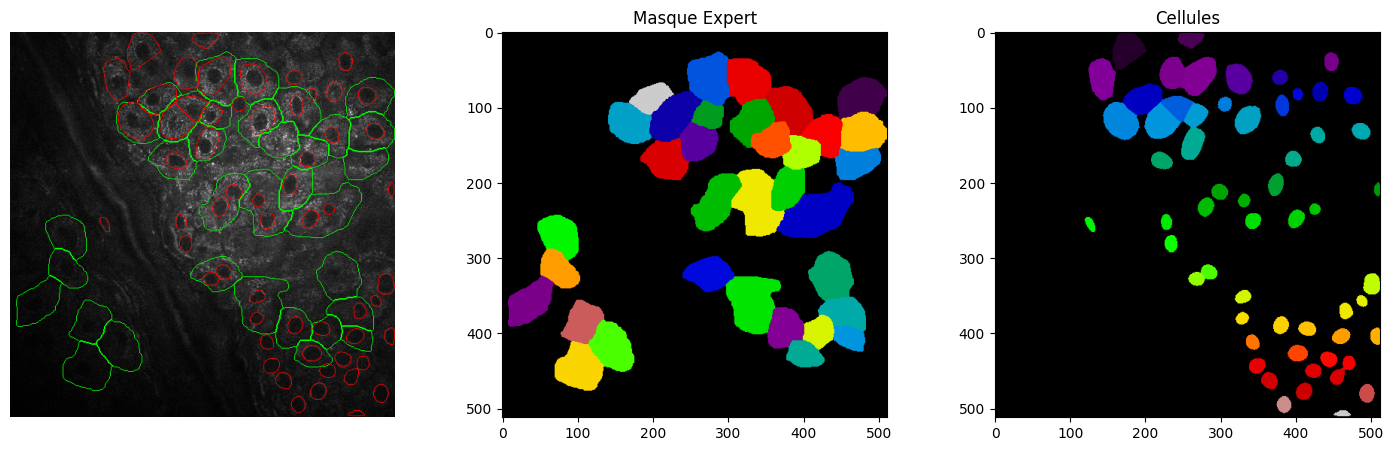

[Cellpose4] F1: 0.087 | TP: 4 | FN: 30


{'f1': 0.08695652335882187,
 'ap': 0.04545454680919647,
 'tp': 4,
 'fp': 54,
 'fn': 30}

In [10]:
true_mask = visualizer.load_data("001", mode='Cell')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
visualizer.plot_overlay(i = "001", mask_pred=masks_pred, ax=ax1, show=False)
visualizer.plot(data = masks_pred, mode = 'Cell_pred', ax=ax3, show=False)
visualizer.plot(i = "001", mode='Cell', ax=ax2, show=False, title="Masque Expert")
plt.show()


ev = tool.Stats()
ev.report("Cellpose4", true_mask, masks_pred)


In [11]:

import random


my_ids = ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010','011', '012', '013', '014', '015', '016', '017', '018', '019', '020','021', '022', '023', '024', '025', '026', '027', '028', '029', '030','031', '032', '033', '034', '035', '036', '037', '038', '039', '040','041', '042', '043', '044', '045', '046', '047', '048', '049', '050'] 


random.seed(42)
random.shuffle(my_ids)

n = len(my_ids)
ids_train = my_ids[:int(0.7 * n)]
ids_val   = my_ids[int(0.7 * n):int(0.8 * n)]
ids_test  = my_ids[int(0.8 * n):]

print(f"Split : Train({len(ids_train)}) | Val({len(ids_val)}) | Test({len(ids_test)})")



Split : Train(35) | Val(5) | Test(10)


2026-03-20 11:09:38,468 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-20 11:09:38,469 [INFO] 
cellpose version: 	4.0.10.dev21+g849ca11f1 
platform:       	linux 
python version: 	3.12.12 
torch version:  	2.10.0+cu128

--- Test LR = 5e-05 ---
2026-03-20 11:09:38,690 [INFO] ** TORCH CUDA version installed and working. **
2026-03-20 11:09:38,691 [INFO] >>>> using GPU (CUDA)
2026-03-20 11:09:40,879 [INFO] >>>> loading model /root/.cellpose/models/cpsam
2026-03-20 11:09:41,798 [INFO] >>> converting bfloat16 network to float32 for training
2026-03-20 11:09:41,808 [INFO] computing flows for labels


100%|██████████| 35/35 [00:06<00:00,  5.10it/s]

2026-03-20 11:09:48,694 [INFO] computing flows for labels



100%|██████████| 5/5 [00:00<00:00,  5.76it/s]

2026-03-20 11:09:49,571 [INFO] >>> computing diameters


...


100%|██████████| 5/5 [00:00<00:00,  5.75it/s]

2026-03-20 11:33:41,953 [INFO] >>> computing diameters



100%|██████████| 5/5 [00:00<00:00, 398.35it/s]

2026-03-20 11:33:42,037 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-03-20 11:33:42,359 [INFO] >>> n_epochs=20, n_train=35, n_test=5
2026-03-20 11:33:42,361 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-03-20 11:33:42,364 [INFO] >>> saving model to models/cyto3_lr_5e-06
2026-03-20 11:34:17,833 [INFO] 0, train_loss=4.1167, test_loss=4.0096, LR=0.000000, time 35.47s
2026-03-20 11:37:03,972 [INFO] 5, train_loss=2.7923, test_loss=2.3012, LR=0.000003, time 201.61s
2026-03-20 11:39:50,724 [INFO] 10, train_loss=2.0412, test_loss=2.0511, LR=0.000005, time 368.36s
2026-03-20 11:44:47,101 [INFO] saving network parameters to models/cyto3_lr_5e-06
2026-03-20 11:45:17,038 [INFO] >>> converting network back to torch.bfloat16 after training
-> Val Loss : 0.0000


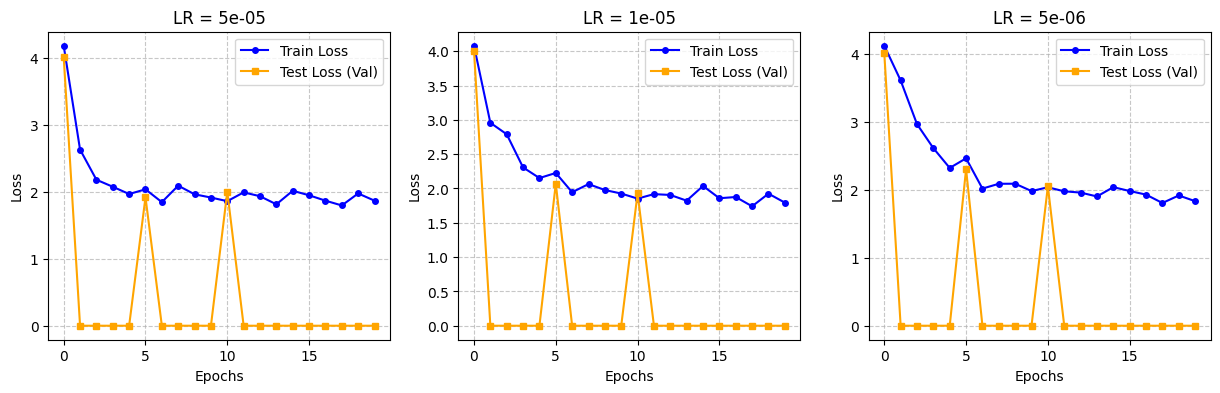

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from cellpose import train, models, io


X_train, Y_train = visualizer.load_set(ids_train)
X_val, Y_val     = visualizer.load_set(ids_val)

# 2. Boucle minimaliste sur les LR
io.logger_setup()
learning_rates = [0.00005, 1e-5, 0.000005] 
fig, axes = plt.subplots(1, len(learning_rates), figsize=(15, 4))

for i, lr in enumerate(learning_rates):
    print(f"\n--- Test LR = {lr} ---")
    
    model = models.CellposeModel(gpu=True)
    
    m_path, t_loss, v_loss = train.train_seg(
        model.net,
        train_data=X_train, train_labels=Y_train,
        test_data=X_val, test_labels=Y_val,
        n_epochs=20,         
        learning_rate=lr,
        weight_decay=0.0001,
        save_path='.',
        model_name=f'cyto4_lr_{lr}'
    )
    
    final_val_loss = v_loss[-1]
    print(f"-> Val Loss : {final_val_loss:.4f}")
    visualizer.plot_loss(t_loss, v_loss, title=f"LR = {lr}", ax=axes[i], show=False)
    

plt.show()


In [9]:
import json

with open('./data/dataset_splits.json', 'r') as f:
    splits = json.load(f)

ids_train = splits['train']
ids_val   = splits['val']
ids_test  = splits['test']

print(f"Splits chargés : Train({len(ids_train)}) | Val({len(ids_val)}) | Test({len(ids_test)})")

Splits chargés : Train(71) | Val(10) | Test(21)


In [10]:
import matplotlib.pyplot as plt
from cellpose import train, models, io

X_train,Y_train = visualizer.load_set(ids_train)
X_val,Y_val   = visualizer.load_set(ids_val)

io.logger_setup()
model_finetune = models.CellposeModel(gpu=True)

model_path, t_loss, v_loss = train.train_seg(
    model_finetune.net,
    train_data=X_train,
    train_labels=Y_train,
    test_data=X_val,
    test_labels=Y_val,
    n_epochs=40,          
    learning_rate=0.05,
    weight_decay=0.0001,  
    save_path='.',
    model_name='cyto4_100'
)

print(f"Modèle sauvegardé : {model_path}")

visualizer.plot_loss(t_loss, v_loss, title=f"LR = {0.05}",show=True)


2026-03-20 12:44:28,091 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-20 12:44:28,093 [INFO] 
cellpose version: 	4.0.10.dev21+g849ca11f1 
platform:       	linux 
python version: 	3.12.12 
torch version:  	2.10.0+cu128
2026-03-20 12:44:28,096 [INFO] ** TORCH CUDA version installed and working. **
2026-03-20 12:44:28,098 [INFO] >>>> using GPU (CUDA)
2026-03-20 12:44:32,357 [INFO] >>>> loading model /root/.cellpose/models/cpsam
2026-03-20 12:44:34,010 [INFO] >>> converting bfloat16 network to float32 for training
2026-03-20 12:44:34,024 [INFO] computing flows for labels


100%|██████████| 71/71 [00:29<00:00,  2.39it/s]

2026-03-20 12:45:03,799 [INFO] computing flows for labels



100%|██████████| 10/10 [00:03<00:00,  2.61it/s]

2026-03-20 12:45:07,661 [INFO] >>> computing diameters



100%|██████████| 10/10 [00:00<00:00, 539.18it/s]

2026-03-20 12:45:07,812 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-03-20 12:45:08,543 [INFO] >>> n_epochs=40, n_train=71, n_test=10
2026-03-20 12:45:08,546 [INFO] >>> AdamW, learning_rate=0.05000, weight_decay=0.00010
2026-03-20 12:45:08,551 [INFO] >>> saving model to models/cyto4_100


OutOfMemoryError: CUDA out of memory. Tried to allocate 16.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 1.81 MiB is free. Process 2647 has 9.36 GiB memory in use. Including non-PyTorch memory, this process has 5.20 GiB memory in use. Of the allocated memory 4.77 GiB is allocated by PyTorch, and 298.92 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [11]:
oc.oc.put_file(
    '/travail/Mines/DIMA/Segmentation/results/models/cyto3_60.pth',
    model_path                                  
)

True

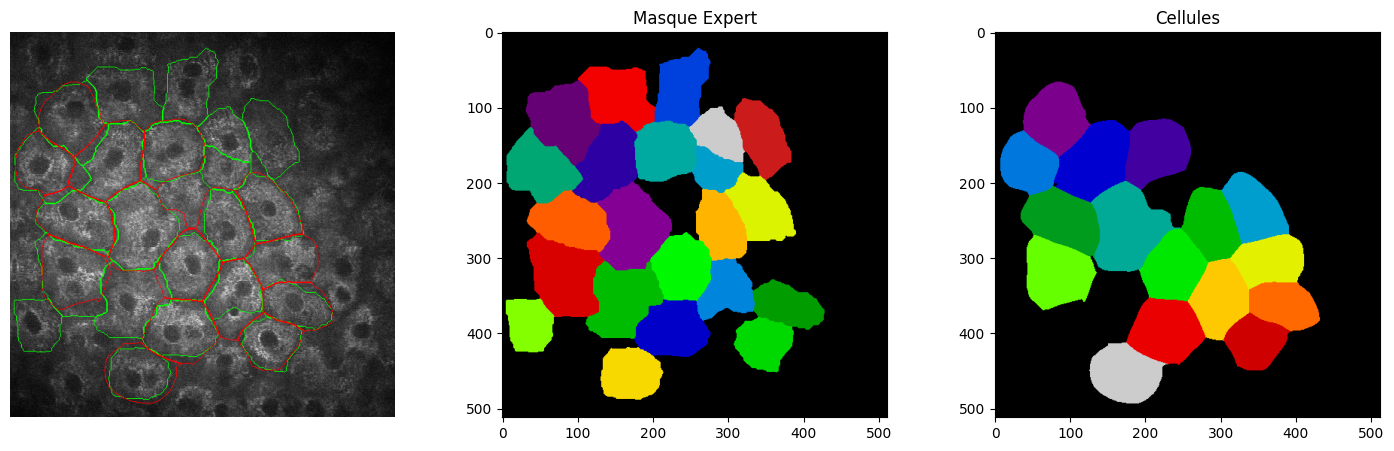


RESULTATS GLOBAUX : Cellpose cyto3
Images evaluees          : 21
Total Vrais Positifs (TP): 265
Total Faux Positifs (FP) : 26
Total Faux Negatifs (FN) : 372
--------------------------------------------------
F1-Score Global (Micro)  : 0.571
F1-Score Moyen (Macro)   : 0.542



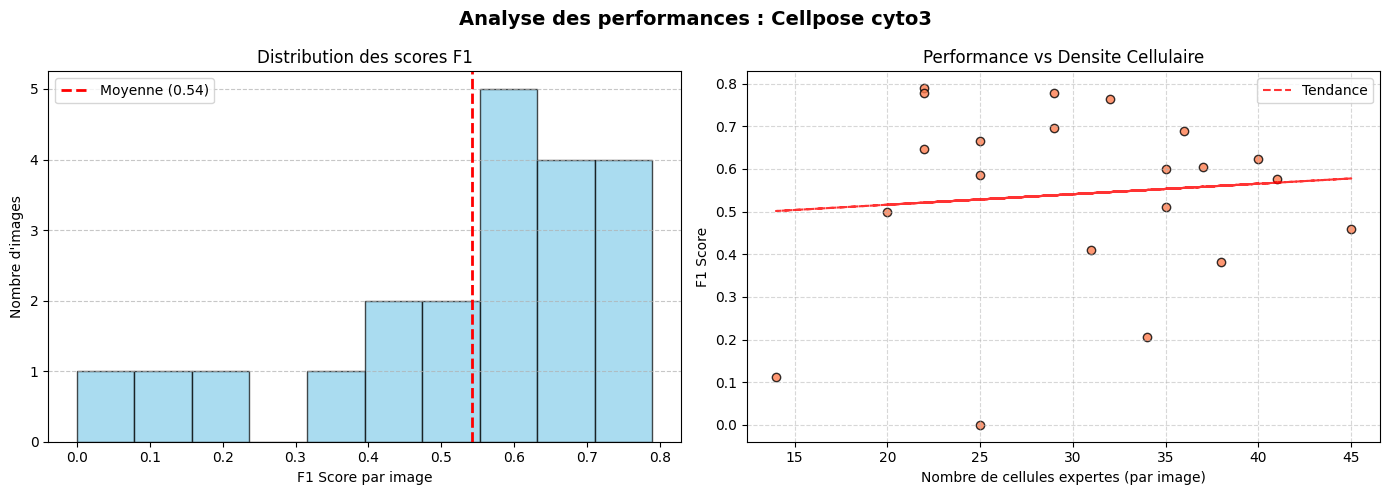

In [12]:
io.logger_setup()
model = models.CellposeModel(gpu=True, pretrained_model= './models/cyto3_60.pth')

output_dir = './data/prediction/cellpose3_60/'
os.makedirs(output_dir, exist_ok=True)

ev = tool.Stats()

all_results = [] 

for img_id in ids_test:
    img = visualizer.load_data(img_id, mode='Image')
    true_mask = visualizer.load_data(img_id, mode='Cell')
    
    masks, flows, styles = model.eval(img, channels=[0,0], resample=True)
    
    save_path = os.path.join(output_dir, f"{img_id}_Cell_pred.bmp")
    cv2.imwrite(save_path, masks)

    all_results.append(ev.report("Cellpose", true_mask, masks, show=False))

    
    if img_id == '065':
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
        visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax1, show=False)
        visualizer.plot(data=masks, mode='Cell_pred', ax=ax3, show=False)
        visualizer.plot(i=img_id, mode='Cell', ax=ax2, show=False, title="Masque Expert")
        plt.show()

df_final = ev.global_report(all_results, model_name="Cellpose cyto3")

In [13]:
oc.download_path('/content/data/prediction/cellpose3_60/','/travail/Mines/DIMA/Segmentation/data/prediction/cellpose3_60/')

Dossier cellpose3_60 envoyé vers /travail/Mines/DIMA/Segmentation/data/prediction/cellpose3_60/.zip
